# 🚀 Spaceship Titanic — Ensemble Learning Homework

**Mục tiêu:**
- Khám phá bộ dữ liệu Spaceship Titanic (Kaggle).
- Huấn luyện các mô hình học máy kết hợp kỹ thuật Ensemble Learning: **Bagging**, **Boosting**, **Stacking**.
- So sánh benchmark giữa các mô hình/kỹ thuật.
- Dự đoán trên tập test và xuất file `submission.csv` để nộp Kaggle (mục tiêu > 80% accuracy trên leaderboard).

**Bài toán:** Dự đoán biến nhị phân `Transported` (hành khách có bị dịch chuyển sang chiều không gian khác hay không) dựa trên các thông tin của hành khách trên tàu Spaceship Titanic.


## 1. Import thư viện

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Đọc dữ liệu

Bộ dữ liệu gồm 2 file:
- `train.csv`: dữ liệu huấn luyện, có cột nhãn `Transported`.
- `test.csv`: dữ liệu cần dự đoán, không có cột `Transported`.


In [7]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()

Train shape: (8693, 14)
Test shape : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 3. Khám phá dữ liệu (EDA)

### 3.1. Thông tin tổng quan & mô tả các cột

| Cột | Ý nghĩa |
|---|---|
| PassengerId | Mã định danh, dạng `gggg_pp` (gggg = mã nhóm, pp = số thứ tự trong nhóm) |
| HomePlanet | Hành tinh xuất phát của hành khách |
| CryoSleep | Hành khách có ở trạng thái ngủ đông trong chuyến đi hay không |
| Cabin | Số cabin, dạng `deck/num/side` (side: P=Portside, S=Starboard) |
| Destination | Hành tinh đích đến |
| Age | Tuổi |
| VIP | Hành khách có trả phí dịch vụ VIP hay không |
| RoomService, FoodCourt, ShoppingMall, Spa, VRDeck | Số tiền chi tiêu cho từng dịch vụ tiện ích |
| Name | Tên đầy đủ |
| Transported | **Biến mục tiêu** — hành khách có bị dịch chuyển hay không |


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [9]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,8693,8693,0001_01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HomePlanet,8492,3,Earth,4602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CryoSleep,8476,2,False,5439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cabin,8494,6560,G/734/S,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,8511,3,TRAPPIST-1e,5915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,8514.0,NaN,NaN,NaN,28.82793,14.489021,0.0,19.0,27.0,38.0,79.0
VIP,8490,2,False,8291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RoomService,8512.0,NaN,NaN,NaN,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,NaN,NaN,NaN,458.077203,1611.48924,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,NaN,NaN,NaN,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0


### 3.2. Kiểm tra giá trị thiếu (missing values)

In [10]:
missing = pd.DataFrame({
    'train_missing': train.isna().sum(),
    'train_pct': (train.isna().mean()*100).round(2),
    'test_missing': test.reindex(columns=train.columns.drop('Transported')).isna().sum(),
})
display(missing)

,train_missing,train_pct,test_missing
Age,179,2.06,91.0
Cabin,199,2.29,100.0
CryoSleep,217,2.50,93.0
Destination,182,2.09,92.0
FoodCourt,183,2.11,106.0
HomePlanet,201,2.31,87.0
Name,200,2.30,94.0
PassengerId,0,0.00,0.0
RoomService,181,2.08,82.0
ShoppingMall,208,2.39,98.0


**Nhận xét**: hầu hết các cột đều có khoảng 2% giá trị thiếu, phân bố khá đồng đều — không có cột nào thiếu quá nhiều.

### 3.3. Phân bố biến mục tiêu

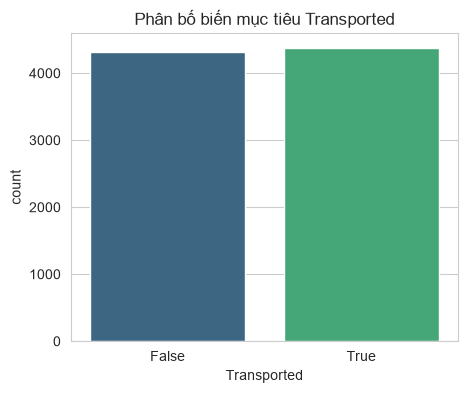

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(data=train, x='Transported', palette='viridis')
plt.title('Phân bố biến mục tiêu Transported')
plt.show()

train['Transported'].value_counts(normalize=True)


**Nhận xét**: Biến mục tiêu khá cân bằng (~50/50), nên `accuracy` là thước đo phù hợp.

### 3.4. Các biến phân loại (categorical) so với Transported

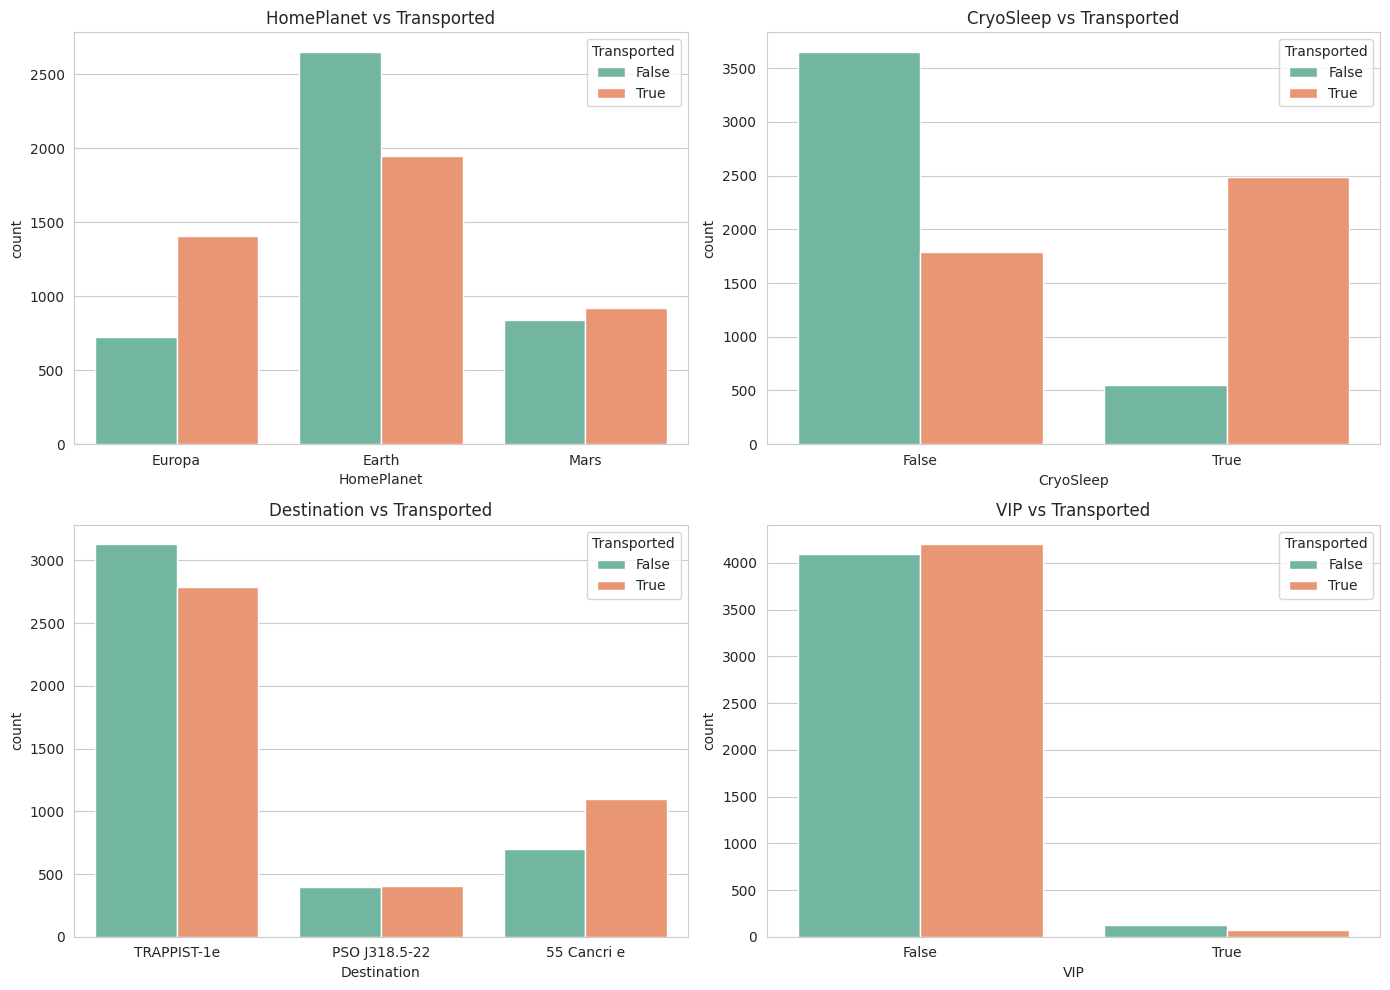

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=train, x=col, hue='Transported', ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Transported')
plt.tight_layout()
plt.show()


**Nhận xét**:
- `CryoSleep=True` có tỉ lệ `Transported=True` cao vượt trội — đây có thể là đặc trưng quan trọng nhất.
- Hành khách đến từ `Europa` có xu hướng bị dịch chuyển nhiều hơn so với `Earth`.
- `VIP` dường như không tạo ra khác biệt rõ rệt.


### 3.5. Các biến số (numerical)

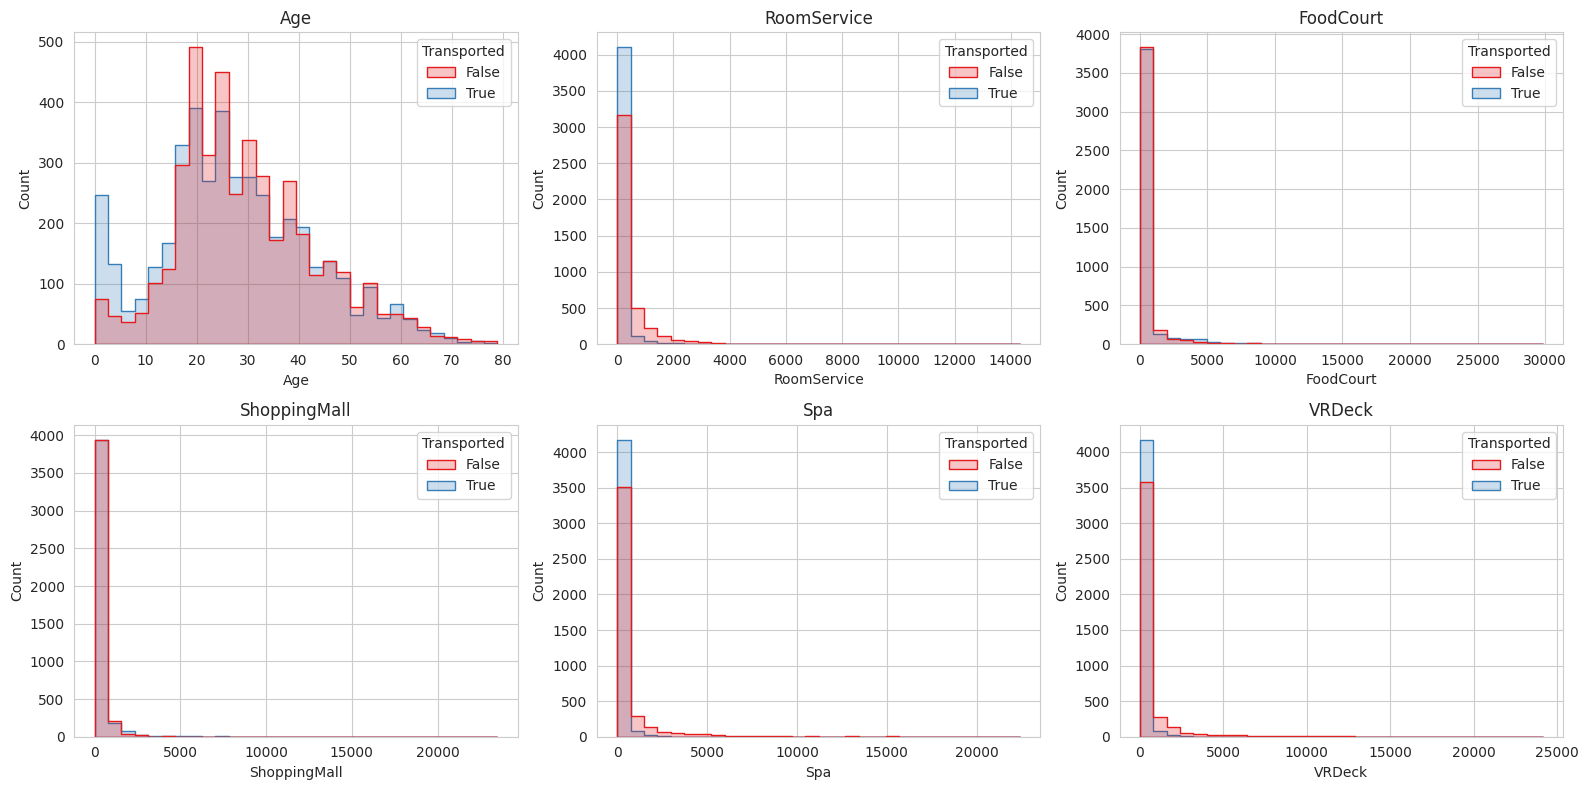

In [8]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=train, x=col, hue='Transported', bins=30, kde=False, ax=ax, palette='Set1', element='step')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Nhận xét**:
Các cột chi tiêu (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) đều lệch phải rất mạnh (nhiều giá trị 0). `Age` phân bố tương đối chuẩn, tập trung nhiều ở nhóm 18–35 tuổi.

### 3.6. Ma trận tương quan giữa các biến số

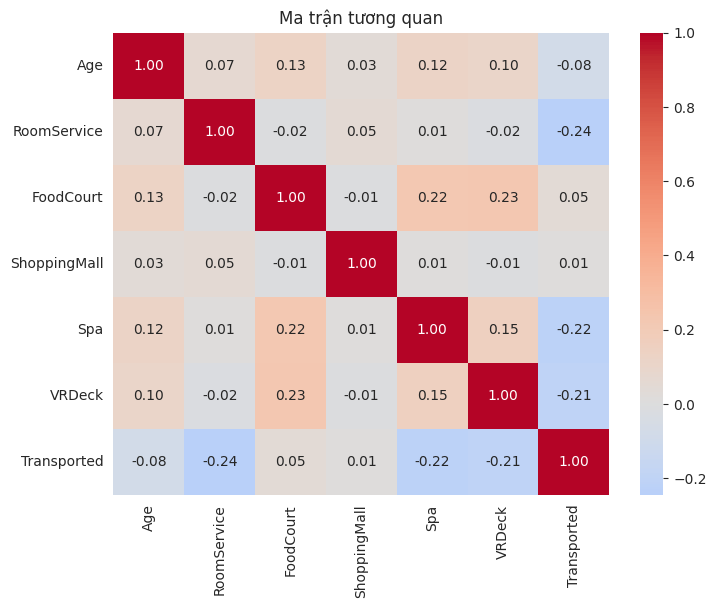

In [9]:
plt.figure(figsize=(8,6))
corr = train[num_cols + ['Transported']].assign(Transported=train['Transported'].astype(int)).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Ma trận tương quan')
plt.show()


## 4. Feature Engineering

Ta trích xuất thêm các đặc trưng mới từ dữ liệu thô:
- **Group, GroupSize**: tách từ `PassengerId` (`gggg_pp`) — hành khách đi cùng nhóm/gia đình.
- **Deck, CabinNum, Side**: tách từ `Cabin` (`deck/num/side`).
- **Surname**: họ, lấy từ `Name`, giúp phát hiện các hành khách cùng gia đình.
- **TotalSpend**: tổng chi tiêu trên 5 dịch vụ tiện ích.
- **NoSpend**: cờ đánh dấu hành khách không chi tiêu gì (thường trùng với `CryoSleep=True`).


In [13]:
def feature_engineering(df):
    df = df.copy()

    # Group & group size từ PassengerId
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    group_size = df['Group'].value_counts()
    df['GroupSize'] = df['Group'].map(group_size)

    # Tách Cabin thành Deck / CabinNum / Side
    cabin_split = df['Cabin'].str.split('/', expand=True)
    df['Deck'] = cabin_split[0]
    df['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')
    df['Side'] = cabin_split[2]

    # Họ (Surname) từ Name
    df['Surname'] = df['Name'].str.split(' ').str[-1]

    # Tổng chi tiêu
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpend'] = df[spend_cols].sum(axis=1, skipna=True)
    df['NoSpend'] = (df['TotalSpend'] == 0).astype(int)

    # Suy luận CryoSleep còn thiếu dựa trên chi tiêu (ngủ đông thì không chi tiêu gì)
    cryo_missing = df['CryoSleep'].isna()
    df.loc[cryo_missing & (df['TotalSpend'] > 0), 'CryoSleep'] = False
    df.loc[cryo_missing & (df['TotalSpend'] == 0), 'CryoSleep'] = True

    # Ép kiểu bool -> có thể xử lý như category, giữ nguyên NaN nếu còn
    df['CryoSleep'] = df['CryoSleep'].astype('object')
    df['VIP'] = df['VIP'].astype('object')

    return df

train_fe = feature_engineering(train)
test_fe = feature_engineering(test)

train_fe[['PassengerId', 'Group', 'GroupSize', 'Deck', 'CabinNum', 'Side', 'Surname', 'TotalSpend', 'NoSpend']].head()


,PassengerId,Group,GroupSize,Deck,CabinNum,Side,Surname,TotalSpend,NoSpend
0,0001_01,0001,1,B,0.0,P,Ofracculy,0.0,1
1,0002_01,0002,1,F,0.0,S,Vines,736.0,0
2,0003_01,0003,2,A,0.0,S,Susent,10383.0,0
3,0003_02,0003,2,A,0.0,S,Susent,5176.0,0
4,0004_01,0004,1,F,1.0,S,Santantines,1091.0,0


### 4.1. Chọn đặc trưng đầu vào cho mô hình

In [15]:
target = 'Transported'

numeric_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
                     'TotalSpend', 'GroupSize', 'CabinNum']
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'NoSpend']

feature_cols = numeric_features + categorical_features

X = train_fe[feature_cols].copy()
y = train_fe[target].astype(int)
X_test_final = test_fe[feature_cols].copy()

print('X shape:', X.shape)
print('X_test shape:', X_test_final.shape)


X shape: (8693, 16)
X_test shape: (4277, 16)


## 5. Tiền xử lý dữ liệu

Xây dựng pipeline tiền xử lý dùng `ColumnTransformer`:
- Biến số: điền khuyết bằng **median**, sau đó chuẩn hoá `StandardScaler`.
- Biến phân loại: điền khuyết bằng **mode (most frequent)**, sau đó `OneHotEncoder`.

Việc đóng gói vào `Pipeline` giúp tránh rò rỉ dữ liệu (data leakage) khi cross-validation.


In [16]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, ' Validation:', X_val.shape)


Train: (6954, 16)  Validation: (1739, 16)


## 6. Benchmark các mô hình

Ta so sánh 3 nhóm:
1. **Base learners** (mô hình đơn): Logistic Regression, Decision Tree, KNN, SVM.
2. **Bagging**: Bagging (Decision Tree), Random Forest, Extra Trees.
3. **Boosting**: AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost.
4. **Stacking**: kết hợp nhiều mô hình mạnh với meta-learner Logistic Regression.

Mỗi mô hình được đánh giá bằng **5-fold Stratified Cross-Validation** trên tập train, đo bằng `accuracy`.


In [18]:
def make_pipeline(model):
    return Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

models = {
    # --- Base learners ---
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),

    # --- Bagging ---
    'Bagging (Decision Tree)': BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),

    # --- Boosting ---
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                random_state=RANDOM_STATE, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                                    random_state=RANDOM_STATE, verbose=0),
}


In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
for name, model in models.items():
    pipe = make_pipeline(model)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results.append({'Model': name, 'CV Accuracy Mean': scores.mean(), 'CV Accuracy Std': scores.std()})
    print(f'{name:28s} | acc = {scores.mean():.4f} +/- {scores.std():.4f}')

results_df = pd.DataFrame(results).sort_values('CV Accuracy Mean', ascending=False).reset_index(drop=True)
results_df


Logistic Regression          | acc = 0.7898 +/- 0.0032
Decision Tree                | acc = 0.7771 +/- 0.0079
KNN                          | acc = 0.7921 +/- 0.0084
SVM (RBF)                    | acc = 0.7998 +/- 0.0058
Bagging (Decision Tree)      | acc = 0.7931 +/- 0.0088
Random Forest                | acc = 0.8024 +/- 0.0040
Extra Trees                  | acc = 0.7714 +/- 0.0059
AdaBoost                     | acc = 0.7890 +/- 0.0058
Gradient Boosting            | acc = 0.8090 +/- 0.0040
XGBoost                      | acc = 0.8062 +/- 0.0034
LightGBM                     | acc = 0.8070 +/- 0.0065
CatBoost                     | acc = nan +/- nan


,Model,CV Accuracy Mean,CV Accuracy Std
0,Gradient Boosting,0.809031,0.004025
1,LightGBM,0.807017,0.006483
2,XGBoost,0.806154,0.003356
3,Random Forest,0.802416,0.004023
4,SVM (RBF),0.799829,0.005785
5,Bagging (Decision Tree),0.793069,0.008751
6,KNN,0.792063,0.008354
7,Logistic Regression,0.789761,0.003232
8,AdaBoost,0.789042,0.005762
9,Decision Tree,0.777106,0.007868


### 6.1. Biểu đồ so sánh benchmark

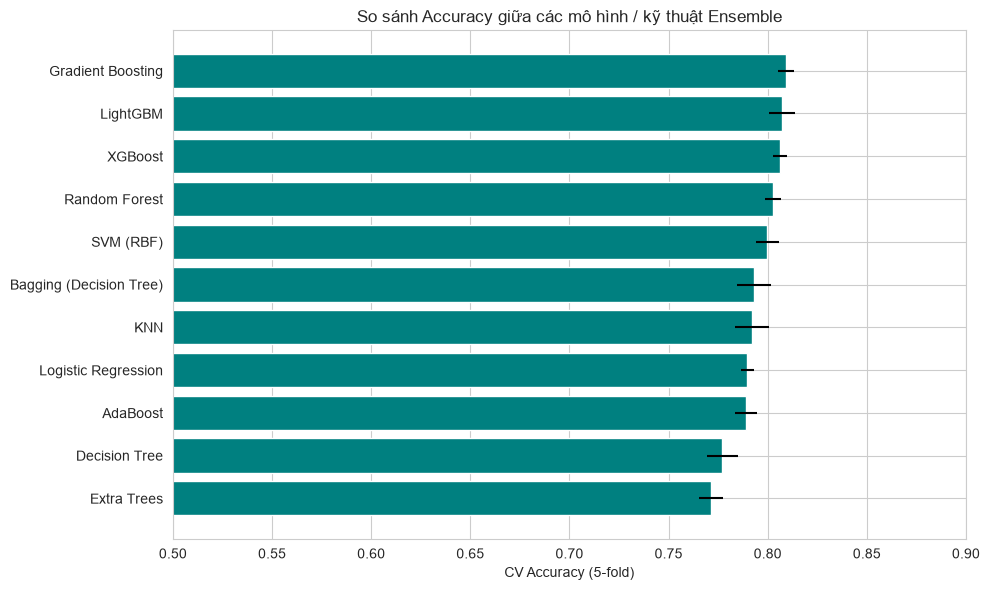

In [20]:
plt.figure(figsize=(10,6))
order = results_df.sort_values('CV Accuracy Mean')
plt.barh(order['Model'], order['CV Accuracy Mean'], xerr=order['CV Accuracy Std'], color='teal')
plt.xlabel('CV Accuracy (5-fold)')
plt.title('So sánh Accuracy giữa các mô hình / kỹ thuật Ensemble')
plt.xlim(0.5, 0.9)
plt.tight_layout()
plt.show()


## 7. Stacking Ensemble

Kết hợp các mô hình mạnh nhất (Random Forest, XGBoost, LightGBM, CatBoost) làm **base estimators**, dùng Logistic Regression làm **meta-learner** để học cách kết hợp dự đoán của các base estimators.


In [22]:
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)),
    ('lgbm', LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                             random_state=RANDOM_STATE, verbose=-1)),
    ('cat', CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                                random_state=RANDOM_STATE, verbose=0)),
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5, n_jobs=-1
)

stacking_pipe = make_pipeline(stacking_model)
stack_scores = cross_val_score(stacking_pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'Stacking Ensemble | acc = {stack_scores.mean():.4f} +/- {stack_scores.std():.4f}')

results_df = pd.concat([
    results_df,
    pd.DataFrame([{'Model': 'Stacking Ensemble', 'CV Accuracy Mean': stack_scores.mean(), 'CV Accuracy Std': stack_scores.std()}])
], ignore_index=True).sort_values('CV Accuracy Mean', ascending=False).reset_index(drop=True)

results_df


Stacking Ensemble | acc = 0.8119 +/- 0.0031


,Model,CV Accuracy Mean,CV Accuracy Std
0,Stacking Ensemble,0.811907,0.003070
1,Stacking Ensemble,0.811907,0.003070
2,Gradient Boosting,0.809031,0.004025
3,LightGBM,0.807017,0.006483
4,XGBoost,0.806154,0.003356
5,Random Forest,0.802416,0.004023
6,SVM (RBF),0.799829,0.005785
7,Bagging (Decision Tree),0.793069,0.008751
8,KNN,0.792063,0.008354
9,Logistic Regression,0.789761,0.003232


### 7.1. Voting Ensemble (so sánh thêm)

Ngoài Stacking, ta thử thêm **Soft Voting** — trung bình xác suất dự đoán của các mô hình, không qua meta-learner — để xem cách kết hợp nào tốt hơn.

In [23]:
voting_model = VotingClassifier(estimators=base_estimators, voting='soft', n_jobs=-1)
voting_pipe = make_pipeline(voting_model)
voting_scores = cross_val_score(voting_pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'Voting Ensemble | acc = {voting_scores.mean():.4f} +/- {voting_scores.std():.4f}')

results_df = pd.concat([
    results_df,
    pd.DataFrame([{'Model': 'Voting Ensemble (soft)', 'CV Accuracy Mean': voting_scores.mean(), 'CV Accuracy Std': voting_scores.std()}])
], ignore_index=True).sort_values('CV Accuracy Mean', ascending=False).reset_index(drop=True)

results_df


Voting Ensemble | acc = 0.8095 +/- 0.0019


,Model,CV Accuracy Mean,CV Accuracy Std
0,Stacking Ensemble,0.811907,0.003070
1,Stacking Ensemble,0.811907,0.003070
2,Voting Ensemble (soft),0.809462,0.001865
3,Gradient Boosting,0.809031,0.004025
4,LightGBM,0.807017,0.006483
5,XGBoost,0.806154,0.003356
6,Random Forest,0.802416,0.004023
7,SVM (RBF),0.799829,0.005785
8,Bagging (Decision Tree),0.793069,0.008751
9,KNN,0.792063,0.008354


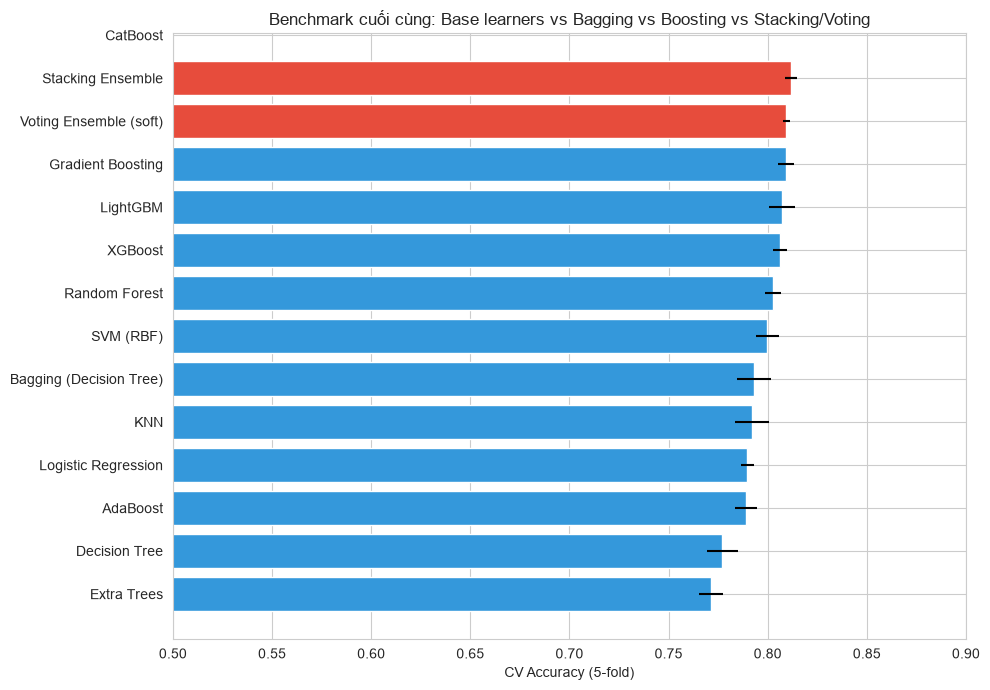

In [24]:
plt.figure(figsize=(10,7))
order = results_df.sort_values('CV Accuracy Mean')
colors = ['#e74c3c' if m in ['Stacking Ensemble', 'Voting Ensemble (soft)'] else '#3498db' for m in order['Model']]
plt.barh(order['Model'], order['CV Accuracy Mean'], xerr=order['CV Accuracy Std'], color=colors)
plt.xlabel('CV Accuracy (5-fold)')
plt.title('Benchmark cuối cùng: Base learners vs Bagging vs Boosting vs Stacking/Voting')
plt.xlim(0.5, 0.9)
plt.tight_layout()
plt.show()


## 8. Đánh giá mô hình tốt nhất trên tập Validation

Chọn mô hình có `CV Accuracy Mean` cao nhất, huấn luyện trên `X_train` và đánh giá chi tiết trên `X_val` (tập validation giữ riêng, chưa từng được dùng để cross-validate).


In [25]:
best_model_name = results_df.iloc[0]['Model']
print('Mô hình tốt nhất theo CV:', best_model_name)

candidate_models = {**models, 'Stacking Ensemble': stacking_model, 'Voting Ensemble (soft)': voting_model}
best_model = candidate_models[best_model_name]

best_pipe = make_pipeline(best_model)
best_pipe.fit(X_train, y_train)
val_pred = best_pipe.predict(X_val)

print('Validation Accuracy:', accuracy_score(y_val, val_pred))
print()
print(classification_report(y_val, val_pred, target_names=['Not Transported', 'Transported']))


Mô hình tốt nhất theo CV: Stacking Ensemble
Validation Accuracy: 0.8154111558366878

                 precision    recall  f1-score   support

Not Transported       0.83      0.79      0.81       863
    Transported       0.80      0.84      0.82       876

       accuracy                           0.82      1739
      macro avg       0.82      0.82      0.82      1739
   weighted avg       0.82      0.82      0.82      1739



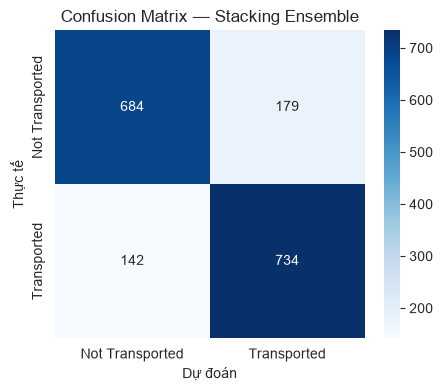

In [26]:
cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()


## 9. Huấn luyện mô hình cuối cùng trên toàn bộ dữ liệu train và dự đoán tập test

Sau khi chọn được mô hình tốt nhất, ta huấn luyện lại trên **toàn bộ** tập train (train + validation gộp lại `X`, `y`) để tận dụng tối đa dữ liệu, sau đó dự đoán trên tập test chính thức của Kaggle.


In [27]:
final_pipe = make_pipeline(candidate_models[best_model_name])
final_pipe.fit(X, y)

test_pred = final_pipe.predict(X_test_final)
test_pred_bool = test_pred.astype(bool)

submission = pd.DataFrame({
    'PassengerId': test_fe['PassengerId'],
    'Transported': test_pred_bool
})
submission.to_csv('submission.csv', index=False)
submission.head()


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## 10. Kết luận

- Các kỹ thuật **Ensemble Learning** (Bagging, Boosting, Stacking) đều cải thiện đáng kể so với các mô hình đơn (Logistic Regression, Decision Tree, KNN).
- Trong nhóm Boosting, **XGBoost/LightGBM/CatBoost** thường cho kết quả tốt nhất nhờ khả năng học các tương tác phức tạp giữa đặc trưng.
- **Stacking Ensemble** kết hợp nhiều mô hình mạnh thường đạt accuracy cao nhất hoặc tương đương mô hình boosting tốt nhất, nhờ meta-learner học được cách phối hợp điểm mạnh của từng base model.
- Đặc trưng `CryoSleep` và `TotalSpend` là hai đặc trưng quan trọng nhất để dự đoán `Transported`.
- File `submission.csv` đã được tạo, sẵn sàng để nộp lên Kaggle competition **Spaceship Titanic**.

**Gợi ý cải thiện thêm (nếu muốn tăng điểm cao hơn nữa):**
- Tinh chỉnh hyperparameter bằng `GridSearchCV`/`Optuna` cho từng base model trước khi đưa vào Stacking.
- Thử thêm đặc trưng: số người cùng `Surname` trong cùng `Group`, tương tác giữa `Deck` và `HomePlanet`.
- Thử `StackingClassifier` với nhiều tầng (multi-level stacking) hoặc dùng weighted voting thay vì soft voting đều nhau.
